In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet

C:\Users\Madhu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
df = pd.read_csv("../data/processed/daily_sales.csv")

df.head()

,Date,Sales
0,2009-12-01,44048.69
1,2009-12-02,52941.99
2,2009-12-03,67479.08
3,2009-12-04,34064.41
4,2009-12-05,9803.05


In [3]:
df["Date"] = pd.to_datetime(df["Date"])

prophet_df = df.rename(
    columns={
        "Date": "ds",
        "Sales": "y"
    }
)

prophet_df = prophet_df[["ds", "y"]]

prophet_df.head()

,ds,y
0,2009-12-01,44048.69
1,2009-12-02,52941.99
2,2009-12-03,67479.08
3,2009-12-04,34064.41
4,2009-12-05,9803.05


In [4]:
prophet_df.shape

(604, 2)

In [5]:
model = Prophet()

model.fit(prophet_df)

23:08:24 - cmdstanpy - INFO - Chain [1] start processing
23:08:25 - cmdstanpy - INFO - Chain [1] done processing


In [6]:
future = model.make_future_dataframe(
    periods=30
)

future.tail()

,ds
629,2012-01-04
630,2012-01-05
631,2012-01-06
632,2012-01-07
633,2012-01-08


In [7]:
forecast = model.predict(future)

forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
629,2012-01-04,17357.008643,1637.997211,33141.471680
630,2012-01-05,25722.856918,9569.754473,42699.287301
631,2012-01-06,17310.685972,2222.660639,32900.063342
632,2012-01-07,-22389.916783,-37632.422327,-7131.489399
633,2012-01-08,10671.249462,-5148.558632,26724.117124


<Figure size 1200x500 with 0 Axes>

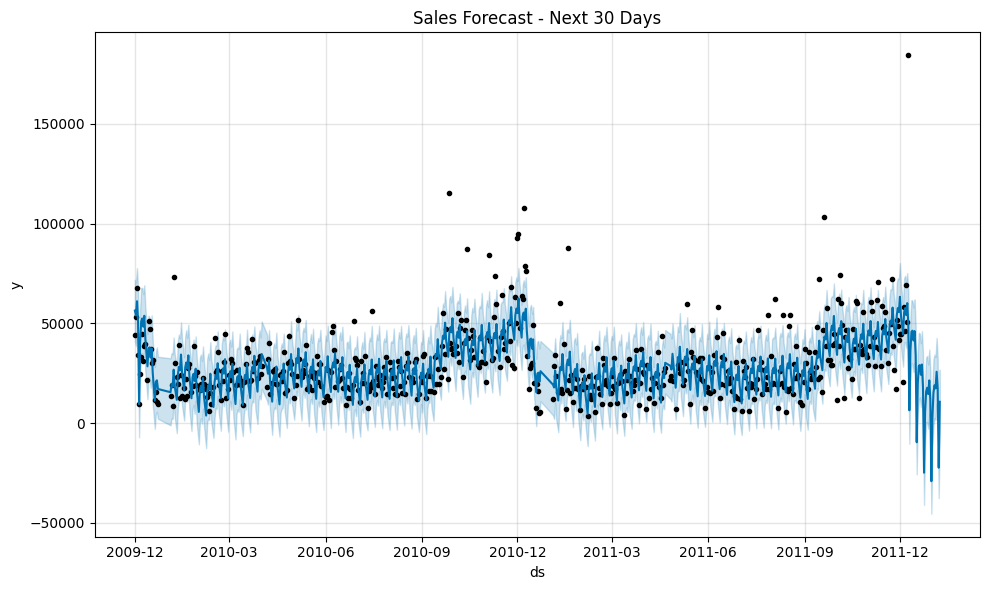

In [8]:
plt.figure(figsize=(12,5))

model.plot(forecast)

plt.title("Sales Forecast - Next 30 Days")
plt.tight_layout()

plt.savefig("../screenshots/forecast_plot.png")

plt.show()

In [9]:
forecast[["ds","yhat","yhat_lower","yhat_upper"]].to_csv(
    "../data/processed/sales_forecast.csv",
    index=False
)

print("Forecast saved successfully!")

Forecast saved successfully!
